In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
np.random.seed(7)

# Učitavanje skupa podataka

In [3]:
data = pd.read_csv('PRSA_data_2010.1.1-2014.12.31.csv')

In [4]:
data.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [5]:
data.columns

Index(['No', 'year', 'month', 'day', 'hour', 'pm2.5', 'DEWP', 'TEMP', 'PRES',
       'cbwd', 'Iws', 'Is', 'Ir'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  str    
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), str(1)
memory usage: 4.3 MB


In [7]:
data.describe()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,Iws,Is,Ir
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,41757.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,21912.500000,2012.000000,6.523549,15.727820,11.500000,98.613215,1.817246,12.448521,1016.447654,23.889140,0.052734,0.194916
std,12651.043435,1.413842,3.448572,8.799425,6.922266,92.050387,14.433440,12.198613,10.268698,50.010635,0.760375,1.415867
min,1.000000,2010.000000,1.000000,1.000000,0.000000,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,10956.750000,2011.000000,4.000000,8.000000,5.750000,29.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,21912.500000,2012.000000,7.000000,16.000000,11.500000,72.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,32868.250000,2013.000000,10.000000,23.000000,17.250000,137.000000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,43824.000000,2014.000000,12.000000,31.000000,23.000000,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


Skup podataka sadrži 43824 reda i 13 kolona. Svaki red predstavlja jedno vremensko merenje koncentracije PM2.5 i odgovarajućih meteoroloških uslova.

Većina atributa je numeričkog tipa, dok je `cbwd` kategorički atribut koji predstavlja smer vetra. Ciljna promenljiva je `pm2.5`, koja predstavlja koncentraciju PM2.5 čestica u vazduhu.

Na osnovu deskriptivne statistike može se uočiti da pojedini atributi imaju širok opseg vrednosti. Posebno se izdvaja ciljna promenljiva `pm2.5`, kod koje je maksimalna vrednost znatno veća od srednje vrednosti i medijane, što ukazuje na asimetričnu raspodelu i prisustvo veoma visokih vrednosti.

# Analiza skupa podataka

In [8]:
data.isnull().sum()

No          0
year        0
month       0
day         0
hour        0
pm2.5    2067
DEWP        0
TEMP        0
PRES        0
cbwd        0
Iws         0
Is          0
Ir          0
dtype: int64

In [9]:
missing = pd.DataFrame({
    'Broj nedostajucih' : data.isnull().sum(),
    'Procenat (%)' : data.isnull().mean() * 100
})

missing.sort_values('Broj nedostajucih', ascending=False)

,Broj nedostajucih,Procenat (%)
pm2.5,2067,4.716594
No,0,0.000000
year,0,0.000000
month,0,0.000000
day,0,0.000000
hour,0,0.000000
DEWP,0,0.000000
TEMP,0,0.000000
PRES,0,0.000000
cbwd,0,0.000000


Nedostajuće vrednosti pojavljuju se samo u koloni `pm2.5`. Ukupno nedostaje 2067 vrednosti, što predstavlja približno 4,72% ukupnog broja zapisa.

Pošto se radi o ciljnoj promenljivoj, redovi koji nemaju vrednost za `pm2.5` ne mogu se koristiti za treniranje i evaluaciju regresionih modela, pa će biti uklonjeni prilikom pripreme podataka.

In [10]:
data.duplicated().sum()

print('Broj dupliranih redova:', data.duplicated().sum())

Broj dupliranih redova: 0


Proverom dupliranih instanci utvrđeno je da u skupu podataka nema potpuno dupliranih redova, pa po ovom osnovu nije potrebno dodatno uklanjanje podataka.

## Analiza kategoričkog atributa 'cbwd'

In [11]:
data.nunique()

No       43824
year         5
month       12
day         31
hour        24
pm2.5      581
DEWP        69
TEMP        64
PRES        60
cbwd         4
Iws       2788
Is          28
Ir          37
dtype: int64

In [12]:
data['cbwd'].unique()

<StringArray>
['NW', 'cv', 'NE', 'SE']
Length: 4, dtype: str

In [13]:
data['cbwd'].value_counts()

cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

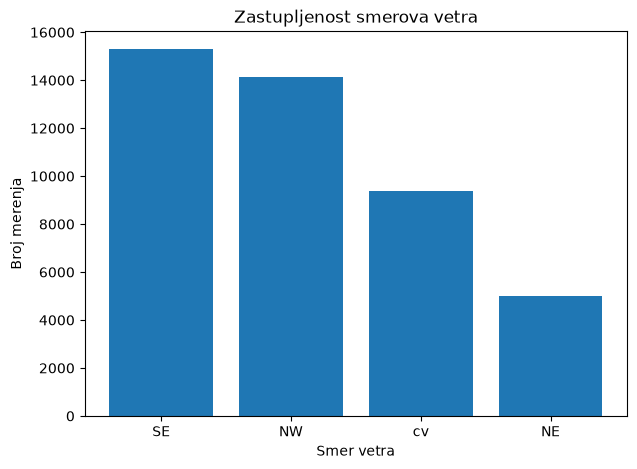

In [14]:
counts = data['cbwd'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(counts.index, counts.values)

plt.xlabel('Smer vetra')
plt.ylabel('Broj merenja')
plt.title('Zastupljenost smerova vetra')

plt.show()

Atribut `cbwd`, koji predstavlja smer vetra, sadrži četiri različite kategorije: `SE`, `NW`, `cv` i `NE`.
Oznake kategorija imaju sledeća značenja:

`SE` - jugoistočni vetar  
`NW` - severozapadni vetar  
`cv` - tih i promenljiv vetar, situacija u kojoj vetar nema dominantan i stabilan smer  
`NE` - severoistočni vetar  

Najzastupljeniji smer vetra je `SE`, zatim `NW` i `cv`, dok je `NE` najmanje zastupljena kategorija. Može se uočiti da kategorije nisu ravnomerno zastupljene, ali pošto `cbwd` predstavlja ulazni atribut, a ne ciljnu promenljivu, ovde se ne radi o problemu nebalansiranosti klasa.

## Analiza ciljne promenljive

In [15]:
data['pm2.5'].describe()

count    41757.000000
mean        98.613215
std         92.050387
min          0.000000
25%         29.000000
50%         72.000000
75%        137.000000
max        994.000000
Name: pm2.5, dtype: float64

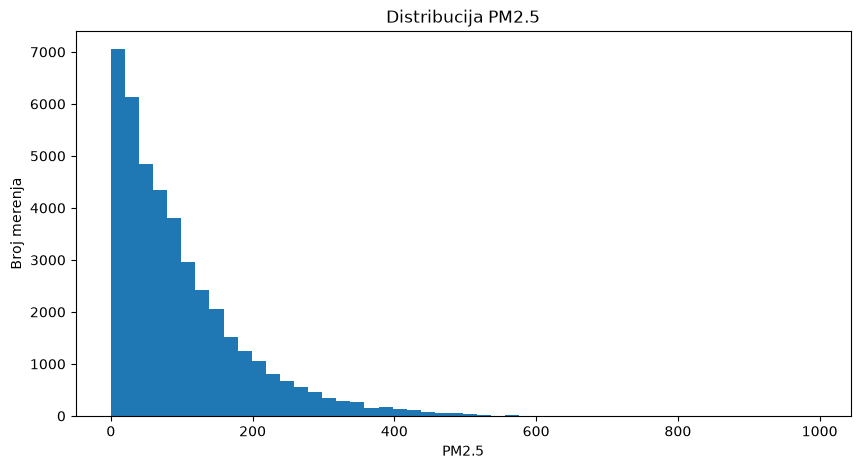

In [16]:
plt.figure(figsize=(10, 5))

plt.hist(data['pm2.5'].dropna(), bins=50)

plt.xlabel('PM2.5')
plt.ylabel('Broj merenja')
plt.title('Distribucija PM2.5')

plt.show()

/var/folders/vm/7yqlck7x7751s7gsnm4dc4_80000gn/T/ipykernel_5676/740631507.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data['pm2.5'].dropna(), vert=False)


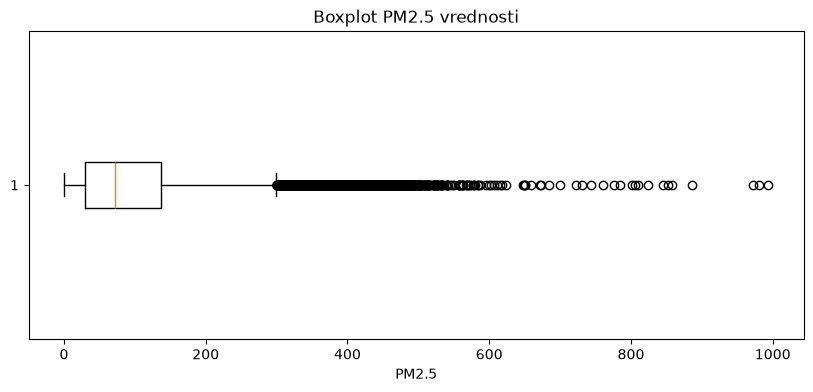

In [17]:
plt.figure(figsize=(10, 4))

plt.boxplot(data['pm2.5'].dropna(), vert=False)

plt.xlabel('PM2.5')
plt.title('Boxplot PM2.5 vrednosti')

plt.show()

Analizom ciljne promenljive `pm2.5` može se uočiti izražena pozitivna asimetrija raspodele. Većina merenja koncentrisana je u oblasti nižih vrednosti PM2.5, dok se javlja manji broj veoma visokih vrednosti.

Srednja vrednost PM2.5 iznosi približno 98,61, dok je medijana 72, a maksimalna zabeležena vrednost 994. Razlika između srednje vrednosti i medijane, kao i veliki raspon vrednosti, dodatno ukazuju na desnu asimetriju raspodele.

Boxplot takođe pokazuje prisustvo većeg broja visokih vrednosti. Ove vrednosti se ne tretiraju automatski kao greške, jer mogu predstavljati stvarne periode veoma visokog zagađenja vazduha, pa ih u ovoj fazi nećemo uklanjati.

## Analiza distribucije numeričkih atributa

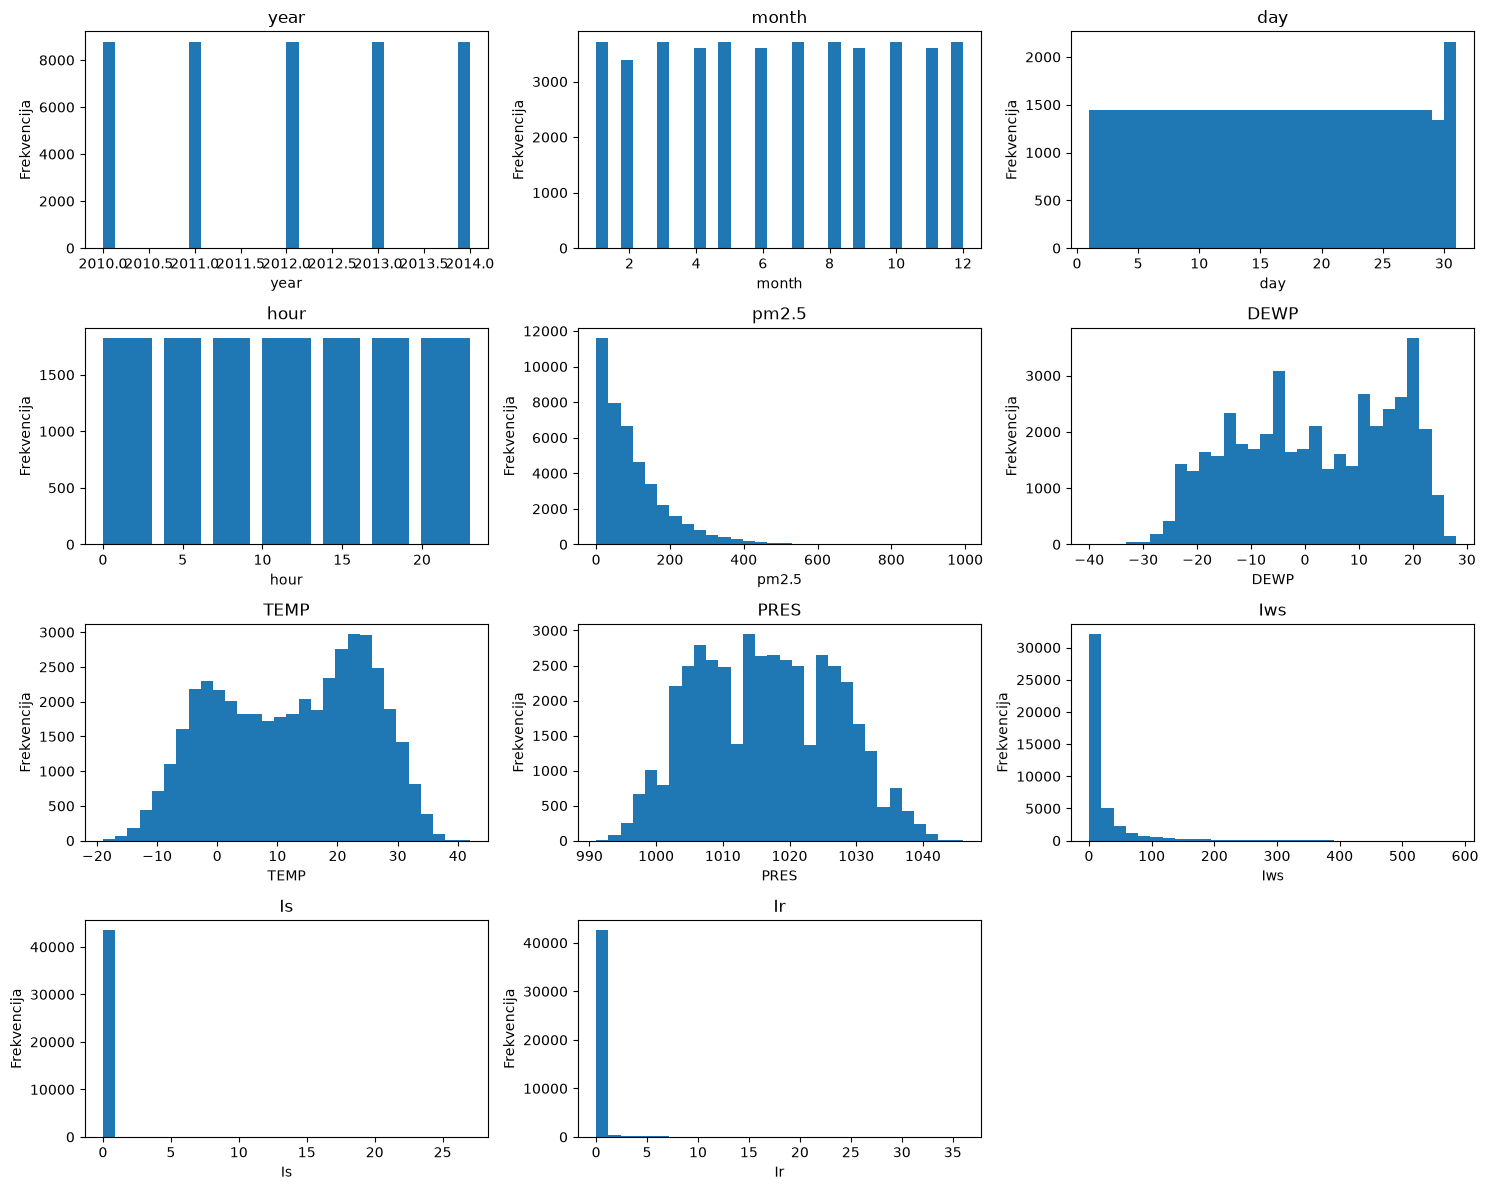

In [18]:
numeric_columns = data.select_dtypes(include='number').columns.drop('No')

plt.figure(figsize=(15, 12))

for i, column in enumerate(numeric_columns):
    plt.subplot(4, 3, i + 1)
    plt.hist(data[column].dropna(), bins=30)
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()

Histogrami pokazuju da numerički atributi imaju različite oblike raspodele i opsege vrednosti. Kod pojedinih meteoroloških atributa raspodele su relativno koncentrisane, dok atributi povezani sa padavinama i brzinom vetra imaju izraženiju asimetriju i veliki broj nižih vrednosti.

Ovakve razlike u raspodelama atributa biće uzete u obzir u fazi pripreme podataka, posebno kod modela koji zahtevaju standardizaciju ulaznih podataka.

## Korelacija atributa sa ciljnom promenljivom PM2.5

In [25]:
feature_names = ['DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir']

In [26]:
data_corr = data.dropna(subset=['pm2.5'])

x = data_corr[feature_names]
y = data_corr['pm2.5']

In [27]:
corrcoefs = []

for feature_name in feature_names:
    corrcoef = np.corrcoef(
        x[feature_name].values, y.values.ravel()
    )[0, 1]

    corrcoefs.append(corrcoef)
    print(feature_name, corrcoef)

DEWP 0.17142327190848045
TEMP -0.09053400243275907
PRES -0.04728230808762519
Iws -0.24778444916507994
Is 0.019265576051499488
Ir -0.051368705541289694


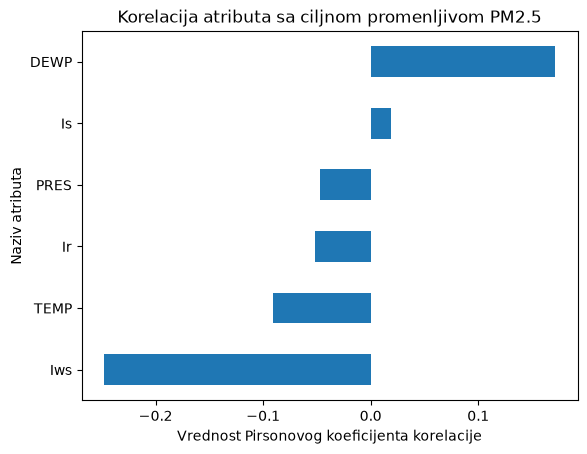

In [28]:
corrcoefs_for_plot = pd.Series(corrcoefs, index=feature_names)
corrcoefs_for_plot.sort_values(inplace=True)

corrcoefs_for_plot.plot(kind='barh')

plt.title('Korelacija atributa sa ciljnom promenljivom PM2.5')
plt.xlabel('Vrednost Pirsonovog koeficijenta korelacije')
plt.ylabel('Naziv atributa')

plt.show()

Analiza Pirsonovog koeficijenta korelacije pokazuje da nijedan od posmatranih numeričkih atributa nema izrazito jaku linearnu povezanost sa ciljnom promenljivom `pm2.5`.

Najizraženiju povezanost pokazuje atribut `Iws`, sa negativnim koeficijentom korelacije od približno -0.25, što ukazuje da je povećanje brzine vetra povezano sa nižim vrednostima PM2.5. Atribut `DEWP` pokazuje slabu pozitivnu korelaciju od približno 0.17, dok ostali posmatrani atributi imaju veoma slabu linearnu korelaciju sa ciljnom promenljivom.

Ovakvi rezultati ukazuju da odnos između meteoroloških uslova i koncentracije PM2.5 verovatno nije moguće u potpunosti opisati jednostavnim linearnim vezama.

## Korelaciona matrica atributa

In [29]:
corr_matrix = x.corr()
corr_matrix

,DEWP,TEMP,PRES,Iws,Is,Ir
DEWP,1.000000,0.823821,-0.777722,-0.293106,-0.034925,0.125341
TEMP,0.823821,1.000000,-0.826903,-0.149613,-0.094785,0.049544
PRES,-0.777722,-0.826903,1.000000,0.178871,0.070537,-0.080532
Iws,-0.293106,-0.149613,0.178871,1.000000,0.022630,-0.009157
Is,-0.034925,-0.094785,0.070537,0.022630,1.000000,-0.009764
Ir,0.125341,0.049544,-0.080532,-0.009157,-0.009764,1.000000


In [30]:
number_of_features = len(feature_names)

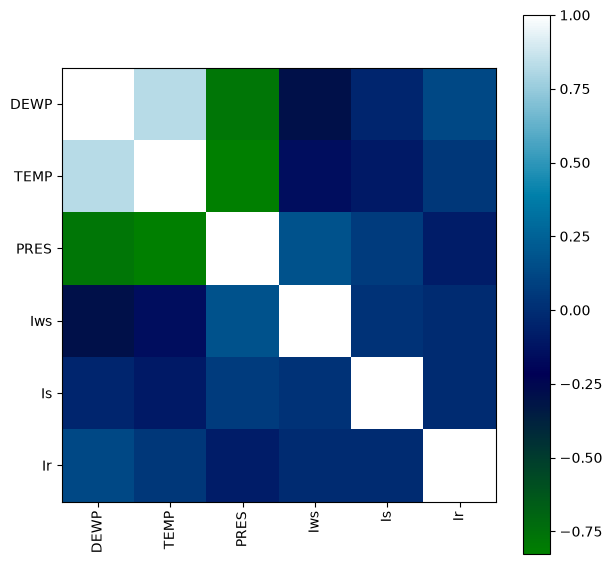

In [31]:
plt.figure(figsize=(7, 7))

plt.xticks(range(number_of_features), feature_names, rotation='vertical')
plt.yticks(range(number_of_features), feature_names)
plt.imshow(corr_matrix, cmap='ocean')
plt.colorbar()
plt.show()

Analizom korelacione matrice može se uočiti izraženija međusobna povezanost pojedinih meteoroloških atributa.

Atributi `DEWP` i `TEMP` imaju jaku pozitivnu korelaciju od približno 0.82, dok između `TEMP` i `PRES` postoji jaka negativna korelacija od približno -0.83. Takođe je prisutna izražena negativna korelacija između `DEWP` i `PRES`, približno -0.78.

Ovi rezultati ukazuju da pojedini meteorološki atributi nose međusobno povezane informacije, što treba imati u vidu prilikom interpretacije rezultata regresionih modela.

## Vremenska analiza koncentracije PM2.5

S obzirom na to da skup podataka sadrži vremenska merenja, analizirana je promena prosečne koncentracije PM2.5 na mesečnom i dnevnom nivou. Na ovaj način moguće je uočiti eventualne sezonske i dnevne obrasce u nivou zagađenja vazduha.

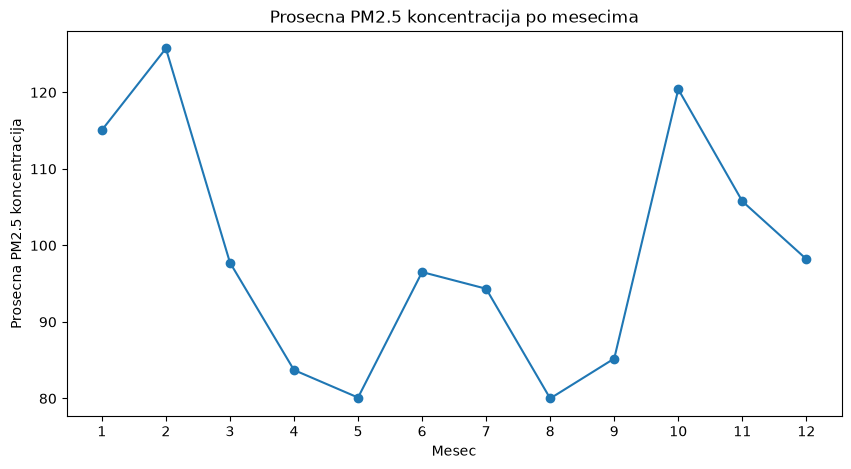

In [32]:
monthly_pm25 = data.groupby('month')['pm2.5'].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_pm25.index, monthly_pm25.values, marker='o')
plt.xticks(range(1, 13))
plt.xlabel('Mesec')
plt.ylabel('Prosecna PM2.5 koncentracija')
plt.title('Prosecna PM2.5 koncentracija po mesecima')
plt.show()

Na mesečnom nivou mogu se uočiti razlike u prosečnoj koncentraciji PM2.5 tokom godine. Više prosečne vrednosti javljaju se tokom hladnijeg dela godine, dok su tokom toplijih meseci koncentracije uglavnom niže.

Ovakva raspodela ukazuje na postojanje sezonskog obrasca u koncentraciji PM2.5, odnosno da mesec u godini može imati značaj za predviđanje nivoa zagađenja.

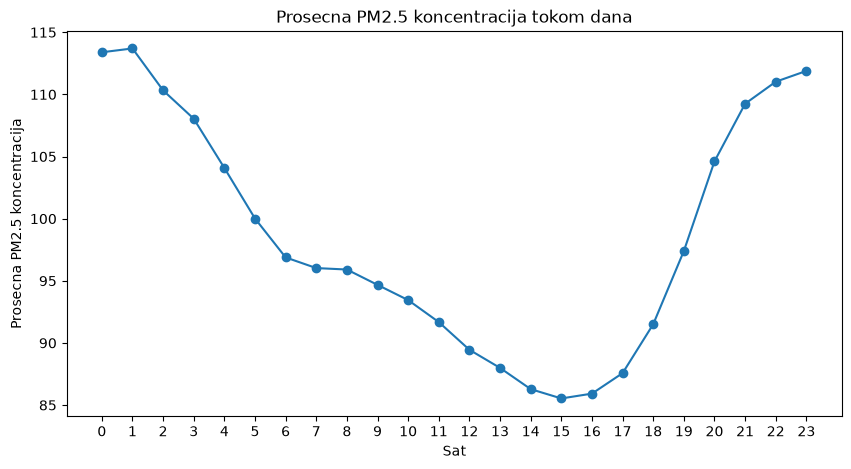

In [33]:
hourly_pm25 = data.groupby('hour')['pm2.5'].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_pm25.index, hourly_pm25.values, marker='o')
plt.xticks(range(24))
plt.xlabel('Sat')
plt.ylabel('Prosecna PM2.5 koncentracija')
plt.title('Prosecna PM2.5 koncentracija tokom dana')
plt.show()

Analiza prosečne koncentracije PM2.5 prema delu dana pokazuje da se nivo zagađenja menja i u toku dana. Uočavaju se periodi sa višim i nižim prosečnim koncentracijama, što ukazuje na postojanje dnevnog obrasca.

Zbog uočenih vremenskih promena, atributi koji opisuju vreme merenja mogu sadržati korisne informacije za predviđanje koncentracije PM2.5.

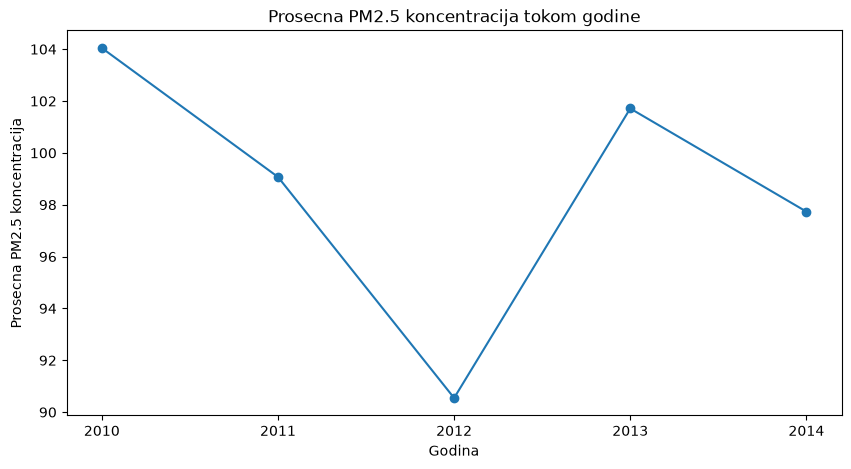

In [22]:
yearly_pm25 = data.groupby('year')['pm2.5'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_pm25.index, yearly_pm25.values, marker='o')
plt.xticks(yearly_pm25.index)
plt.xlabel('Godina')
plt.ylabel('Prosecna PM2.5 koncentracija')
plt.title('Prosecna PM2.5 koncentracija tokom godine')
plt.show()

Prosečna koncentracija PM2.5 nije ista za sve godine u posmatranom periodu. Pojedine godine imaju znatno više, a druge niže prosečne vrednosti, pri čemu se koncentracija ne kreće u jednom smeru već varira od godine do godine.

Za razliku od promena unutar dana i tokom meseci, ovde se ne može govoriti o pravilnom obrascu, pa su razlike između godina uslovljene meteorološkim prilikama i drugim spoljašnjim faktorima specifičnim za svaku godinu.

# Zaključak

Na osnovu sprovedene analize može se zaključiti da skup podataka sadrži dovoljan broj podataka i atributa za formiranje modela za predviđanje koncentracije PM2.5.

Analizom nedostajućih vrednosti utvrđeno je da se one javljaju samo kod ciljnog atributa `pm2.5`, dok ostali atributi nemaju nedostajuće vrednosti. U skupu podataka nisu uočeni duplirani redovi.

Analiza distribucije atributa pokazala je da pojedini atributi imaju izraženu asimetričnost i ekstremne vrednosti. Posebno se izdvaja koncentracija PM2.5, kod koje se javljaju visoke vrednosti u odnosu na najveći broj merenja.

Vremenska analiza pokazala je da koncentracija PM2.5 nije konstantna tokom vremena. Uočavaju se razlike između pojedinih meseci, kao i promene koncentracije tokom dana, što ukazuje na postojanje sezonskih i dnevnih obrazaca.

Korelaciona analiza pokazala je da nijedan od posmatranih meteoroloških atributa nema jaku linearnu povezanost sa koncentracijom PM2.5, dok između pojedinih ulaznih atributa postoje izraženije međusobne korelacije.

Na osnovu sprovedene analize, pre formiranja modela potrebno je izvršiti odgovarajuću pripremu podataka, koja obuhvata obradu nedostajućih vrednosti, uklanjanje atributa koji nisu potrebni za modeliranje i transformaciju kategorijalnih podataka u numerički oblik. Nakon toga podaci se mogu podeliti na skupove za obučavanje, validaciju i testiranje modela.